In [1]:
import logging

logger = logging.getLogger("cmdstanpy")
logger.setLevel(logging.CRITICAL)
logger.propagate = False
logger.handlers = []
logger.disabled = True

import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
# %matplotlib notebook
import glob
import cmdstanpy
from bayes_drt2.inversion import Inverter
import bayes_drt2.file_load as fl
import bayes_drt2.plotting as bp

# from cmdstanpy import install_cmdstan
# install_cmdstan(compiler='msvc')

MultiplexedPath('C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\stan_model_files')


In [2]:
def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header

In [3]:
# series += 1
    # freq_vec_old = [1,2]
# file_in = "C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt"
file_in = r"C:\Users\Herman\Desktop\MFF\Diplomka\Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\Data z PEMWE\IV_Day5_procedure1_05_PEIS.mpt"
skip_rows = get_header_lines(file_in)
with open(file_in, encoding='latin1') as f:
    df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,40),delimiter = '\t')
        
unique_vals = np.unique(df["cycle number"].values)

# E = 0
# E_control, booster = get_EIS_setting(file_in)
# print(E_control)


E_control = 'Ewe'

# if cycles is None:
cycles = unique_vals
    # cycles = unique_vals[0::100]
# for i,val in enumerate(cycles):
for val in range(1,2):
    # sample_spectrum_number += 1

    f = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
    # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
    if E_control == 'Ewe':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
    elif E_control == 'Ewe-Ece':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe-Ece>/V'].values)
        # Z_exp = np.flip(Z_exp)
        # freq_vec = np.flip(freq_vec)
        # I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        # time = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'time/s'].values)
    f = f[2:]
    Z = Z[2:]



C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


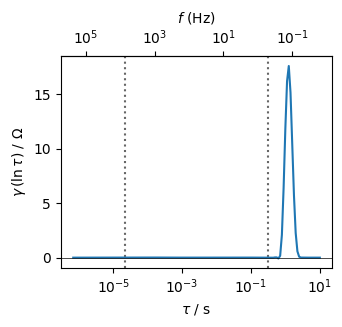

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1550: UserWarning: Possible outliers were identified at indices [[53]], f=[[2.2924006]] Hz. Check the residuals and consider re-running with outliers=True
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


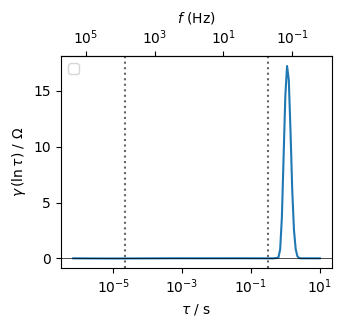

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1440: UserWarning: Identified likely outliers at indices [[47]
 [53]
 [62]
 [63]], f=[[5.723443  ]
 [2.2924006 ]
 [0.58202344]
 [0.50035226]] Hz. An outlier-robust error model will be used. To disable this behavior, pass outliers=False.
  warnings.warn(


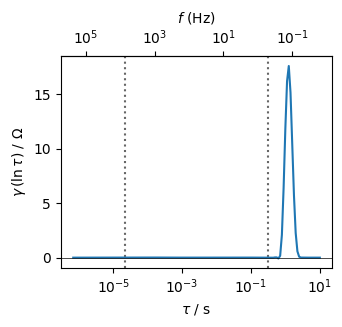

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


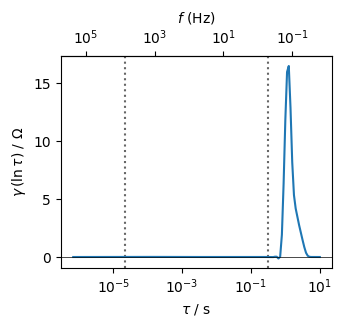

In [4]:
inv_true = Inverter()
inv_true.fit(f, Z, mode='optimize',nonneg = False,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_true.plot_distribution()
plt.show()

inv_false = Inverter()
inv_false.fit(f, Z, mode='optimize',nonneg = False,outliers = False,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_false.plot_distribution(legend = True)
plt.show()

inv_auto = Inverter()
inv_auto.fit(f, Z, mode='optimize',nonneg = False,outliers = 'auto',warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_auto.plot_distribution()
plt.show()

inv_manual = Inverter()
inv_manual.fit(np.delete(f,53), np.delete(Z,53), mode='optimize',nonneg = False,outliers = False,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_manual.plot_distribution()
plt.show()

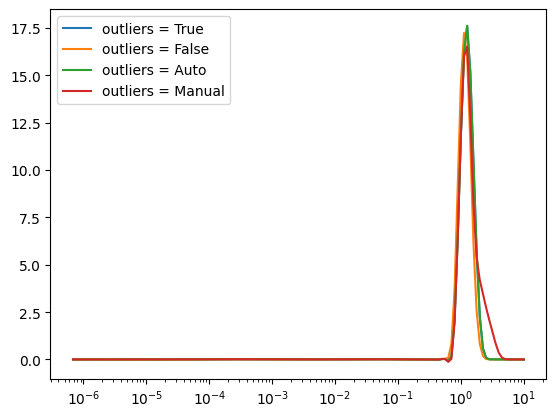

In [6]:
plt.plot(inv_true.tau_plot,inv_true.distribution_f,label = 'outliers = True')
plt.plot(inv_false.tau_plot,inv_false.distribution_f,label = 'outliers = False')
plt.plot(inv_auto.tau_plot,inv_auto.distribution_f, label = 'outliers = Auto')
plt.plot(inv_manual.tau_plot,inv_manual.distribution_f, label = f'outliers = Manual')
plt.xscale('log')
plt.legend()
plt.show()

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1440: UserWarning: Identified likely outliers at indices [[47]
 [53]
 [62]
 [63]], f=[[5.723443  ]
 [2.2924006 ]
 [0.58202344]
 [0.50035226]] Hz. An outlier-robust error model will be used. To disable this behavior, pass outliers=False.
  warnings.warn(


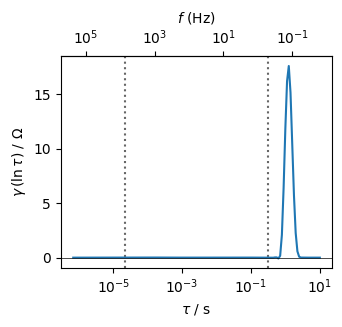

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1440: UserWarning: Identified likely outliers at indices [[47]
 [53]
 [62]
 [63]], f=[[5.723443  ]
 [2.2924006 ]
 [0.58202344]
 [0.50035226]] Hz. An outlier-robust error model will be used. To disable this behavior, pass outliers=False.
  warnings.warn(


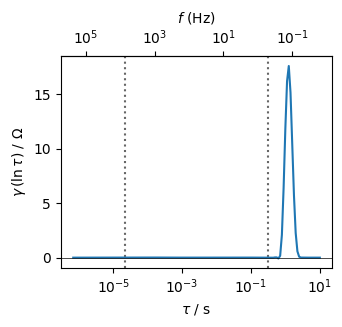

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1440: UserWarning: Identified likely outliers at indices [[ 5]
 [11]
 [35]
 [43]
 [47]
 [48]
 [49]
 [50]
 [51]
 [52]
 [53]
 [54]
 [55]
 [56]
 [61]
 [62]
 [63]], f=[[3.4411013e+03]
 [1.3804421e+03]
 [3.5603844e+01]
 [1.0528975e+01]
 [5.7234430e+00]
 [4.9135222e+00]
 [4.2184124e+00]
 [3.6252902e+00]
 [3.1125500e+00]
 [2.6736827e+00]
 [2.2924006e+00]
 [1.9683801e+00]
 [1.6910173e+00]
 [1.4532179e+00]
 [6.7763901e-01]
 [5.8202344e-01]
 [5.0035226e-01]] Hz. An outlier-robust error model will be used. To disable this behavior, pass outliers=False.
  warnings.warn(


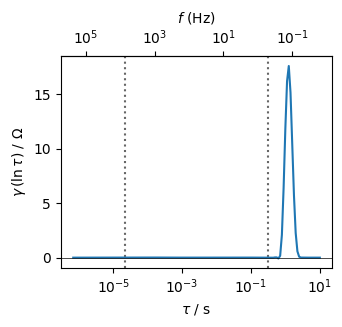

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:1550: UserWarning: Possible outliers were identified at indices [[53]], f=[[2.2924006]] Hz. Check the residuals and consider re-running with outliers=True
  warnings.warn(


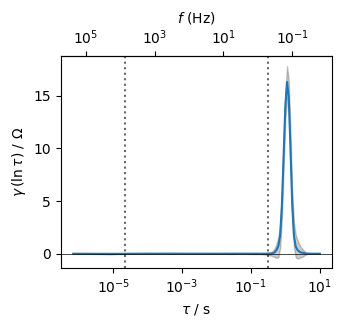

In [7]:
inv_true2 = Inverter()
inv_true2.fit(f, Z, mode='optimize',nonneg = False,outliers = 'auto',outliers_threshold = 2,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_true2.plot_distribution()
plt.show()

inv_true4 = Inverter()
inv_true4.fit(f, Z, mode='optimize',nonneg = False,outliers = 'auto',outliers_threshold = 4,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_true4.plot_distribution()
plt.show()

inv_true1 = Inverter()
inv_true1.fit(f, Z, mode='optimize',nonneg = False,outliers = 'auto',outliers_threshold = 0.01,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_true1.plot_distribution()
plt.show()

inv_false = Inverter()
inv_false.fit(f, Z, mode='sample',nonneg = False,outliers = False,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
inv_false.plot_distribution()
plt.show()



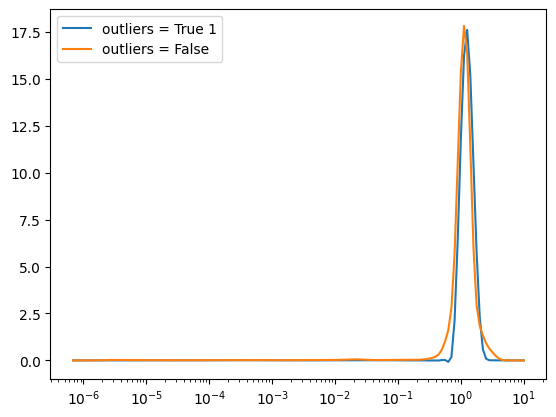

In [9]:
plt.plot(inv_true1.tau_plot,inv_true1.distribution_f,label = 'outliers = True 1')
# plt.plot(inv_true2.tau_plot,inv_true2.distribution_f,label = 'outliers = True 2')
# plt.plot(inv_true4.tau_plot,inv_true4.distribution_f,label = 'outliers = True 4')
plt.plot(inv_false.tau_plot,inv_false.distribution_f,label = 'outliers = False')
plt.xscale('log')
plt.legend()
plt.show()

In [16]:
print(inv_true.score(f,Z))
print(inv_false.score(f,Z))
print(inv_auto.score(f,Z))
print(inv_manual.score(f,Z))

0.001077942231890742
0.0010687040202286822
0.001077942231890742
recalculated pred mat
0.001074874335367438


array([[<Axes: xlabel='$Z^\\prime \\ / \\ \\mathrm{}\\Omega$', ylabel='$-Z^{\\prime\\prime} \\ / \\ \\mathrm{}\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$Z^\\prime$ / $\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-$$Z^{\\prime\\prime}$ / $\\Omega$'>],
       [<Axes: xlabel='$\\tau$ / s', ylabel='$\\gamma \\, (\\ln{\\tau})$ / $\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$\\hat{Z}^{\\prime}-Z^{\\prime}$ / m$\\Omega$'>,
        <Axes: xlabel='$f$ / Hz', ylabel='$-(\\hat{Z}^{\\prime\\prime}-Z^{\\prime\\prime})$ / m$\\Omega$'>]],
      dtype=object)

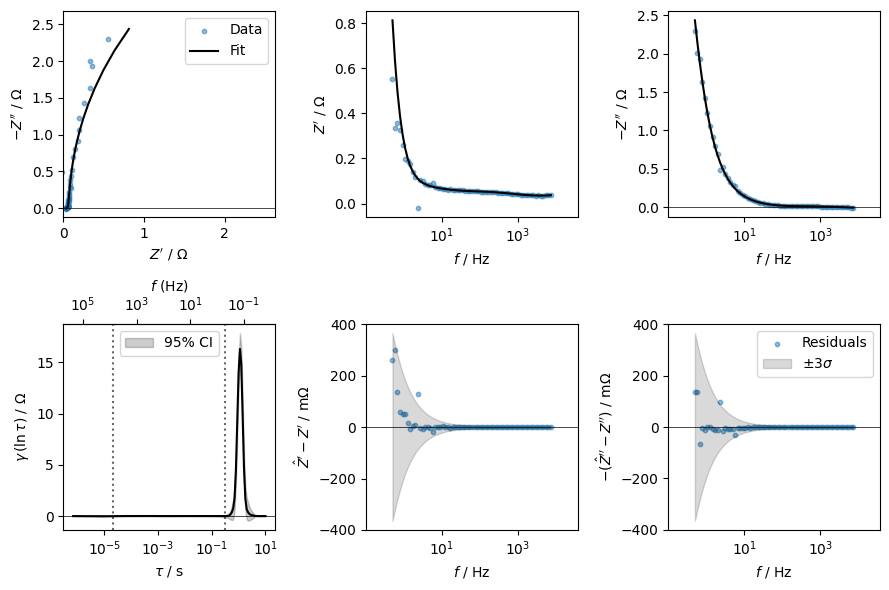

In [10]:
inv_false.plot_full_results()

In [10]:
1/inv_true.get_distributions()['DRT']['tau']*1/6.28


array([7.37822435e+04, 5.85058915e+04, 4.63924541e+04, 3.67870609e+04,
       2.91704304e+04, 2.31307962e+04, 1.83416468e+04, 1.45440739e+04,
       1.15327749e+04, 9.14495478e+03, 7.25152431e+03, 5.75012191e+03,
       4.55957955e+03, 3.61553477e+03, 2.86695111e+03, 2.27335905e+03,
       1.80266812e+03, 1.42943207e+03, 1.13347323e+03, 8.98791617e+02,
       7.12699999e+02, 5.65137991e+02, 4.48128173e+02, 3.55344823e+02,
       2.81771938e+02, 2.23432057e+02, 1.77171241e+02, 1.40488564e+02,
       1.11400905e+02, 8.83357425e+01, 7.00461401e+01, 5.55433352e+01,
       4.40432845e+01, 3.49242786e+01, 2.76933305e+01, 2.19595246e+01,
       1.74128829e+01, 1.38076072e+01, 1.09487911e+01, 8.68188271e+00,
       6.88432967e+00, 5.45895362e+00, 4.32869663e+00, 3.43245534e+00,
       2.72177763e+00, 2.15824322e+00, 1.71138661e+00, 1.35705008e+00,
       1.07607767e+00, 8.53279605e-01, 6.76611088e-01, 5.36521161e-01,
       4.25436356e-01, 3.37351267e-01, 2.67503883e-01])

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


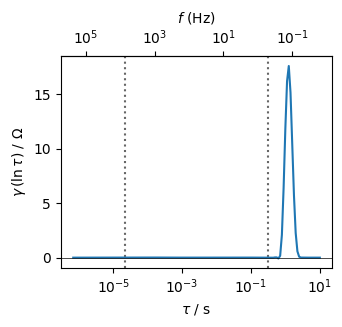

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


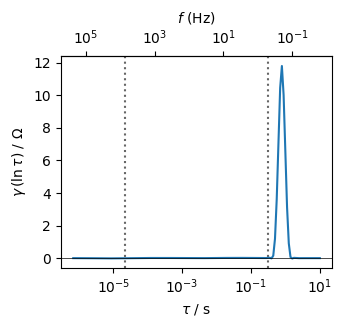

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


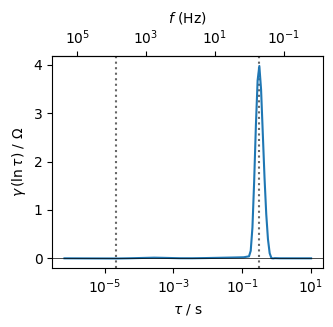

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


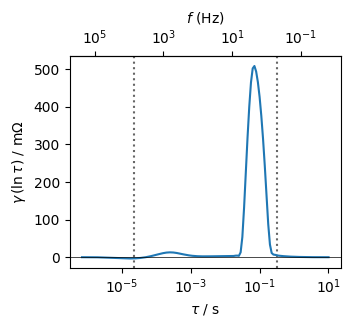

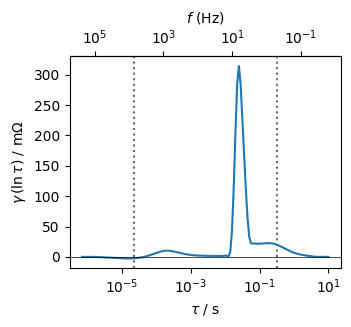

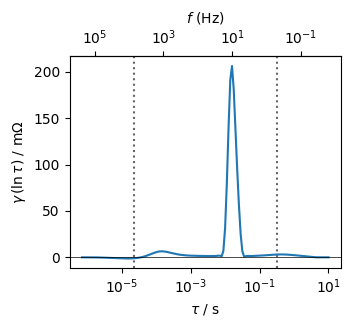

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


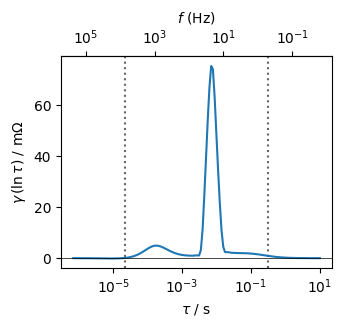

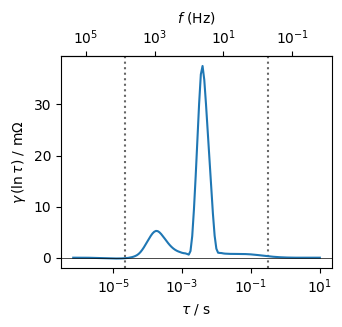

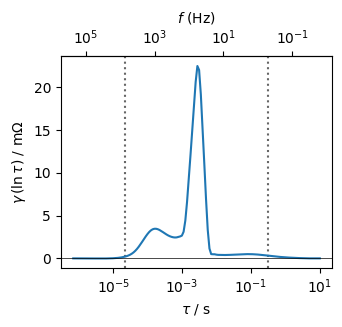

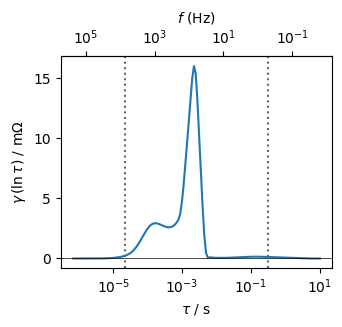

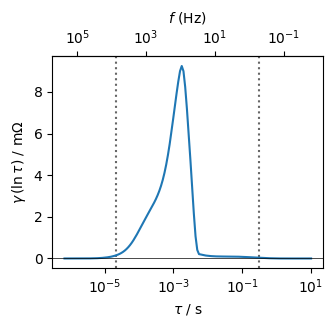

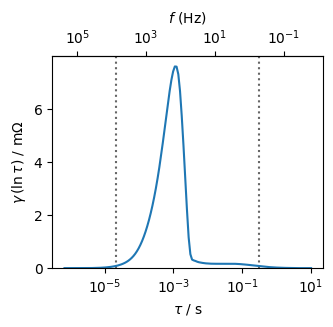

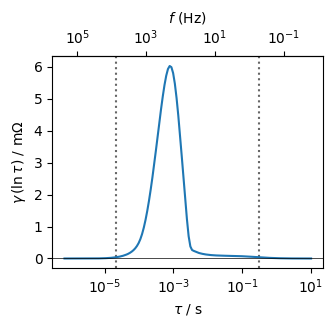

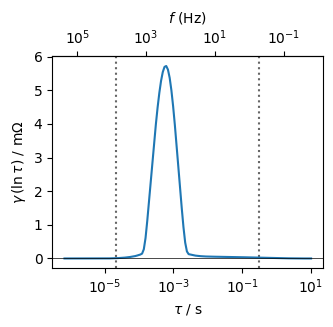

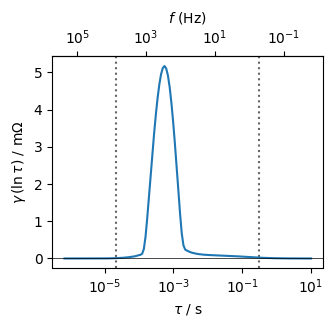

In [4]:
file_in = r"C:\Users\Herman\Desktop\MFF\Diplomka\Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\Data z PEMWE\IV_Day5_procedure1_05_PEIS.mpt"
skip_rows = get_header_lines(file_in)
with open(file_in, encoding='latin1') as f:
    df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,40),delimiter = '\t')
        
unique_vals = np.unique(df["cycle number"].values)
E_control = 'Ewe'

tau_plots = []
gammas = []

cycles = unique_vals
for val in range(1,16):
    # sample_spectrum_number += 1

    f = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
    # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
    if E_control == 'Ewe':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
    elif E_control == 'Ewe-Ece':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
    f = f[2:]
    Z = Z[2:]
    
    inv = Inverter()
    inv.fit(f, Z, mode='optimize',nonneg = False,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
    inv.plot_distribution()
    plt.show()
    gammas.append(inv.final_gamma)
    tau_plots.append(inv.tau_plot)



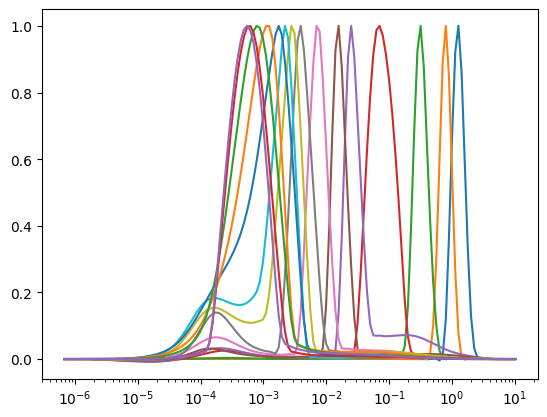

In [6]:
for tau,gamma in zip(tau_plots, gammas):
    plt.plot(tau,gamma/max(gamma))
plt.xscale('log')

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

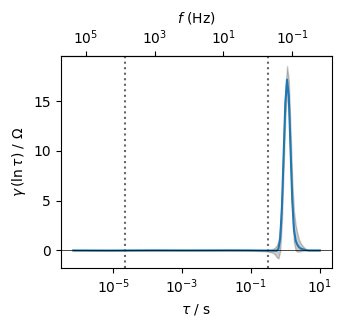

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

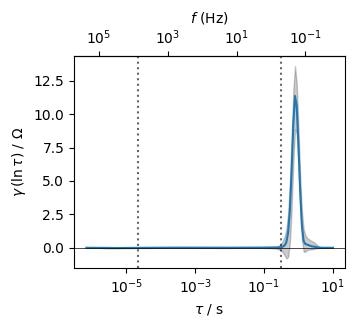

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

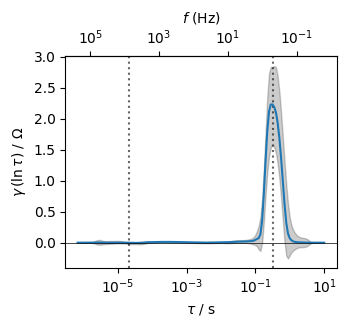

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

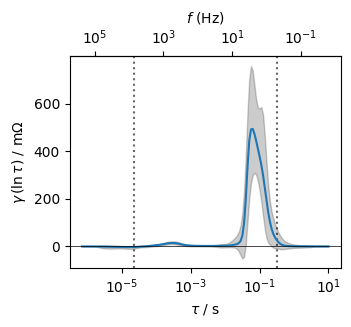

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

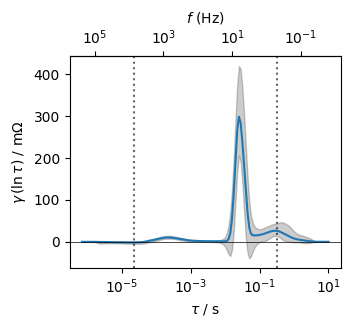

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

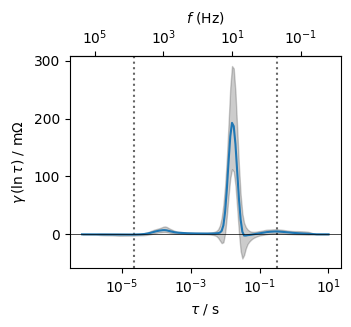

C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

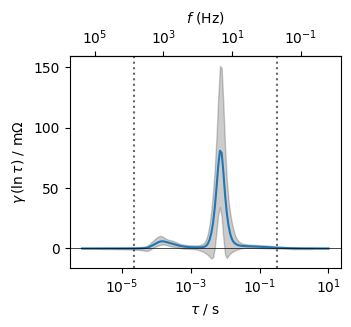

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

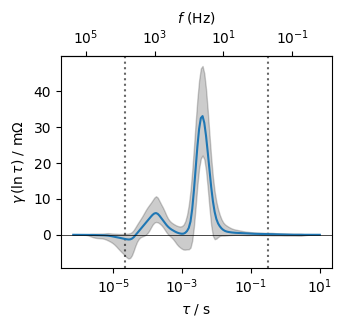

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

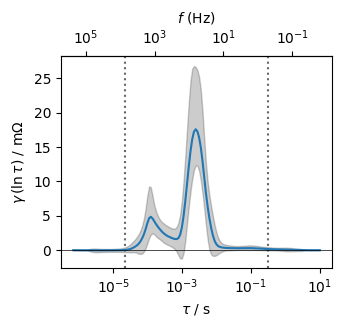

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

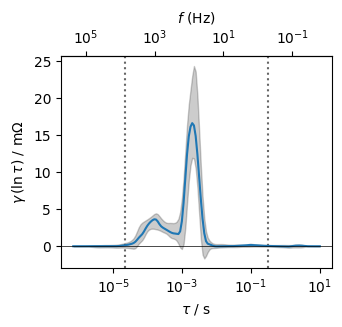

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

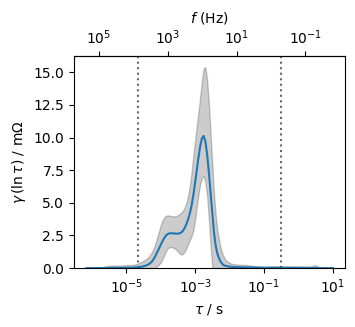

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

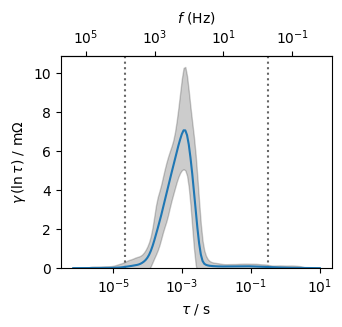

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

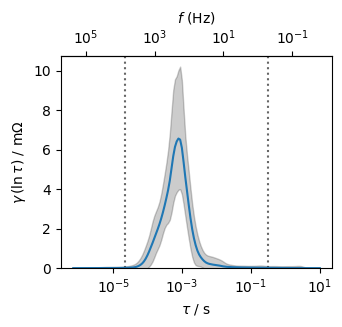

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

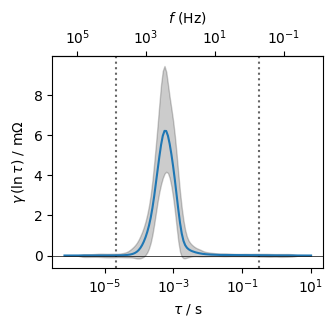

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

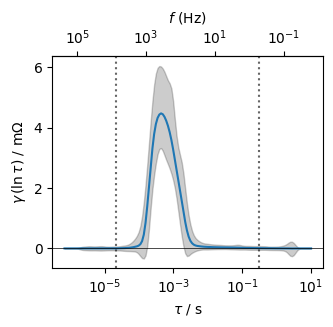

In [7]:
file_in = r"C:\Users\Herman\Desktop\MFF\Diplomka\Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\Data z PEMWE\IV_Day5_procedure1_05_PEIS.mpt"
skip_rows = get_header_lines(file_in)
with open(file_in, encoding='latin1') as f:
    df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,40),delimiter = '\t')
        
unique_vals = np.unique(df["cycle number"].values)
E_control = 'Ewe'

tau_plots_hmc = []
gammas_hmc = []

cycles = unique_vals
for val in range(1,16):
    # sample_spectrum_number += 1

    f = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
    # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
    if E_control == 'Ewe':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
    elif E_control == 'Ewe-Ece':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
    f = f[2:]
    Z = Z[2:]
    
    inv = Inverter()
    inv.fit(f, Z, mode='sample',nonneg = False,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
    inv.plot_distribution()
    plt.show()
    gammas_hmc.append(inv.final_gamma)
    tau_plots_hmc.append(inv.tau_plot)



C:\Users\Herman\anaconda3\lib\site-packages\bayes_drt2\inversion.py:877: UserWarning: Optimal lambda_0 1e-10 determined by Re-Im CV is at the boundary of the evaluated range. Re-run with an expanded lambda_0 range to obtain an accurate estimate of the optimal lambda_0.
  warnings.warn(


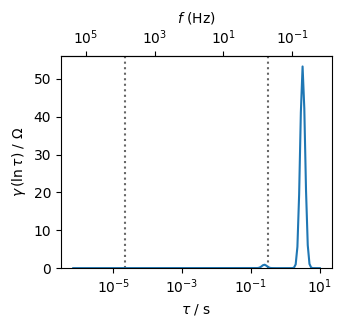

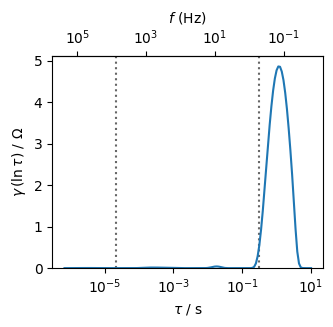

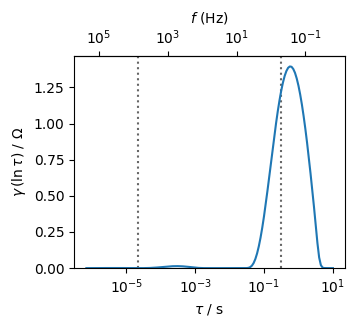

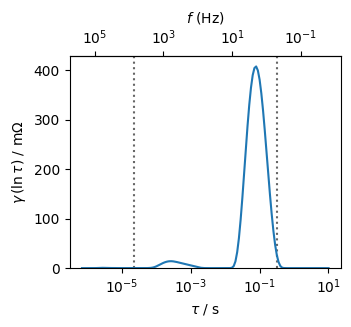

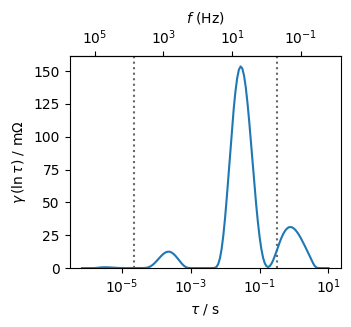

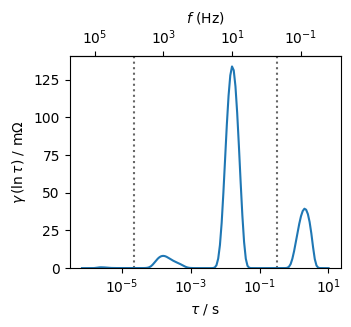

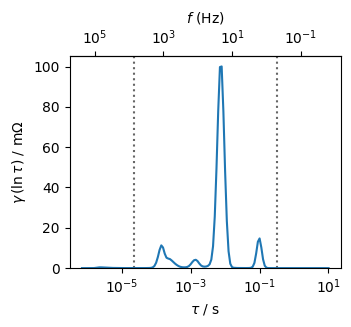

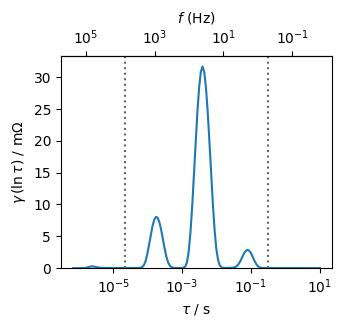

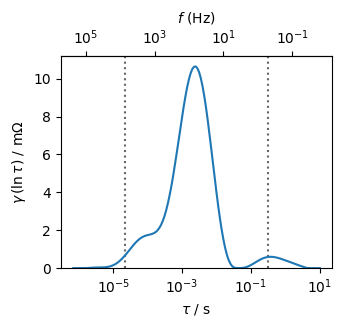

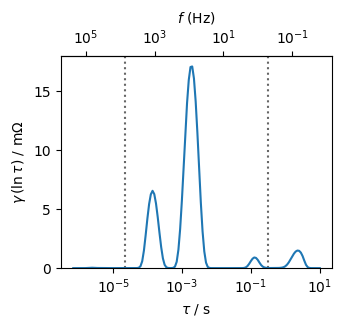

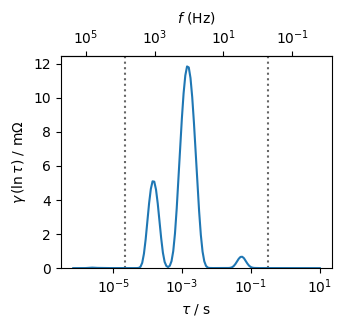

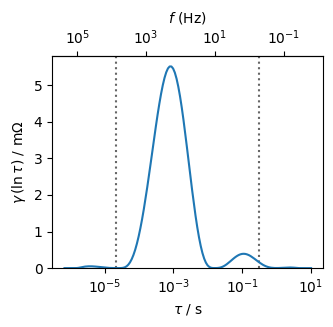

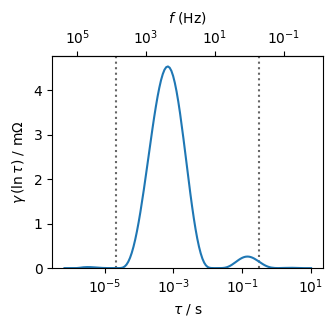

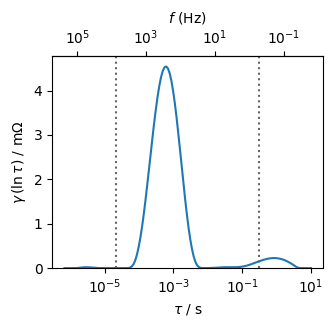

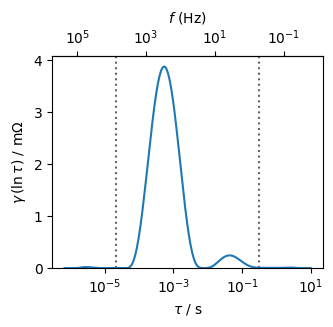

In [20]:
file_in = r"C:\Users\Herman\Desktop\MFF\Diplomka\Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\Data z PEMWE\IV_Day5_procedure1_05_PEIS.mpt"
skip_rows = get_header_lines(file_in)
with open(file_in, encoding='latin1') as f:
    df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,40),delimiter = '\t')
        
unique_vals = np.unique(df["cycle number"].values)
E_control = 'Ewe'

tau_plots_ridge = []
gammas_ridge = []

cycles = unique_vals
for val in range(1,16):
    # sample_spectrum_number += 1

    f = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
    # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
    if E_control == 'Ewe':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        # E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
    elif E_control == 'Ewe-Ece':
        Z = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
    f = f[2:]
    Z = Z[2:]
    
    inv = Inverter()
    inv.ridge_fit(f, Z, nonneg = True,hyper_lambda = False,preset = 'Ciucci')  # initialize from ridge solution
    inv.plot_distribution()
    plt.show()
    gammas_ridge.append(inv.final_gamma)
    tau_plots_ridge.append(inv.tau_plot)



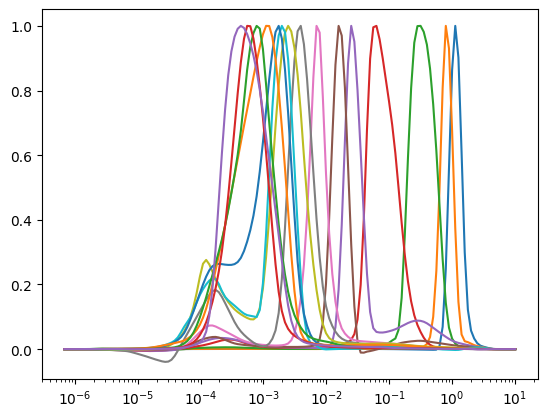

In [8]:
for tau,gamma in zip(tau_plots_hmc, gammas_hmc):
    plt.plot(tau,gamma/max(gamma))
plt.xscale('log')

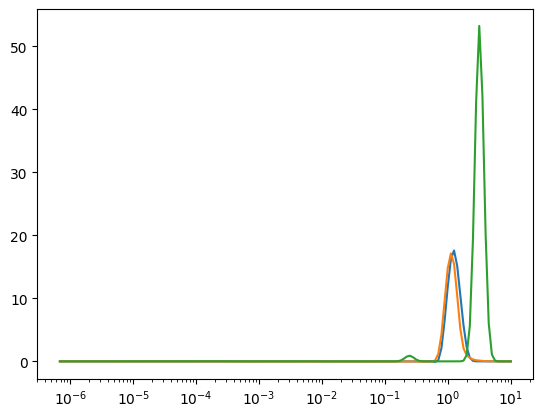

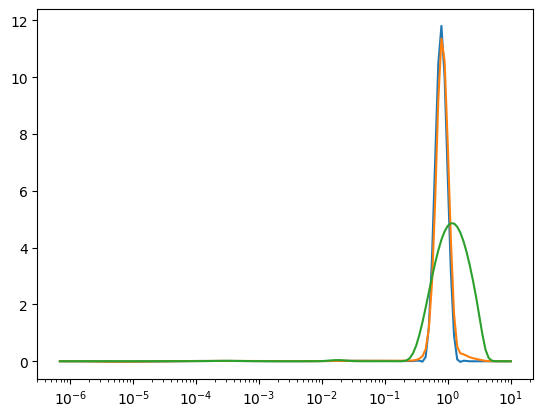

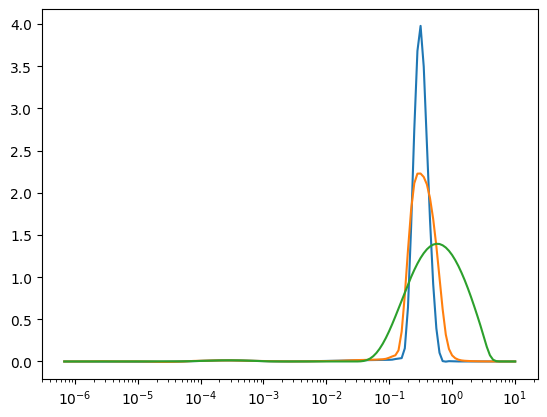

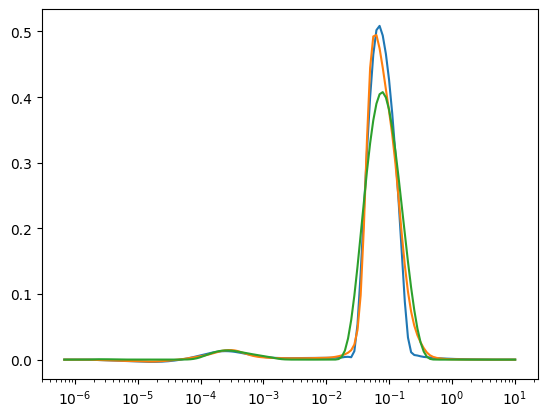

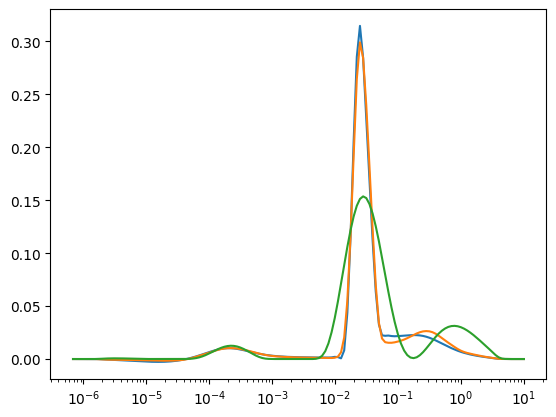

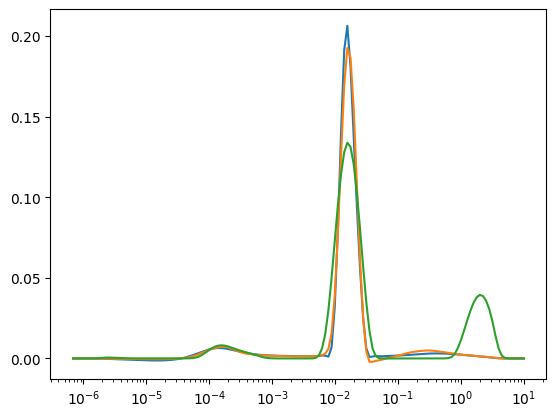

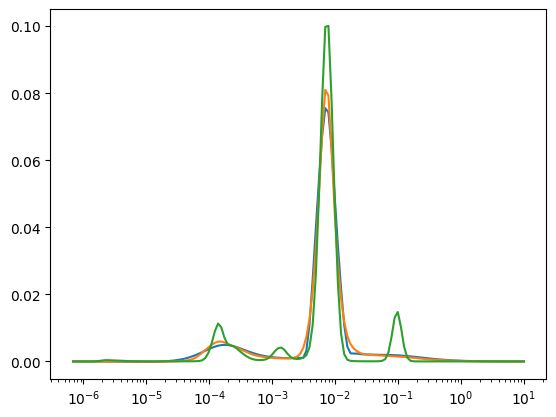

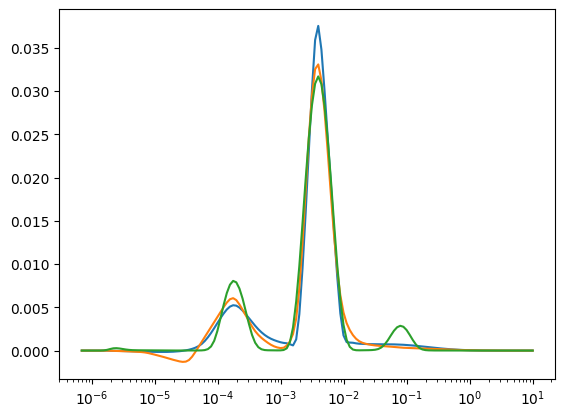

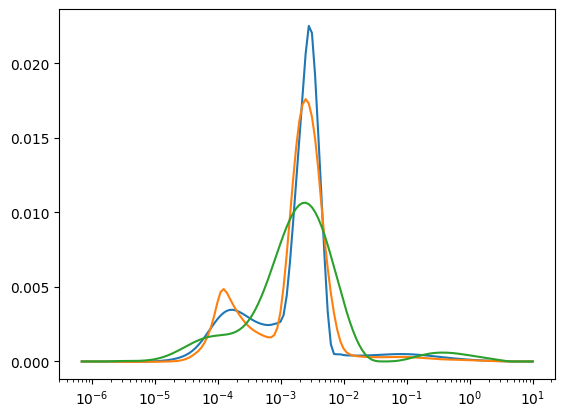

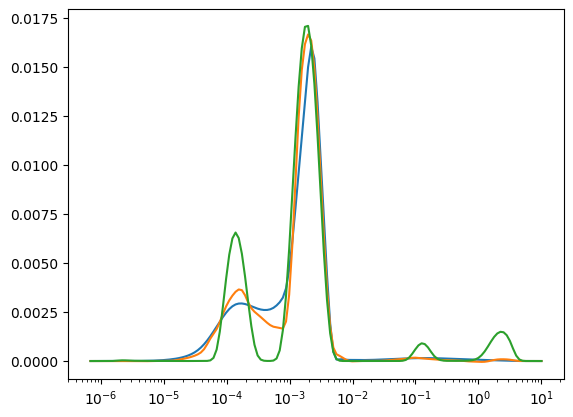

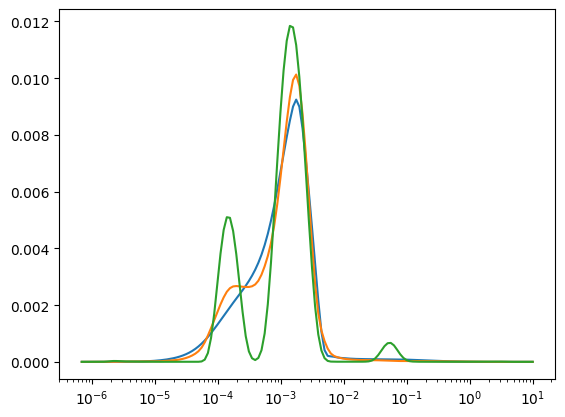

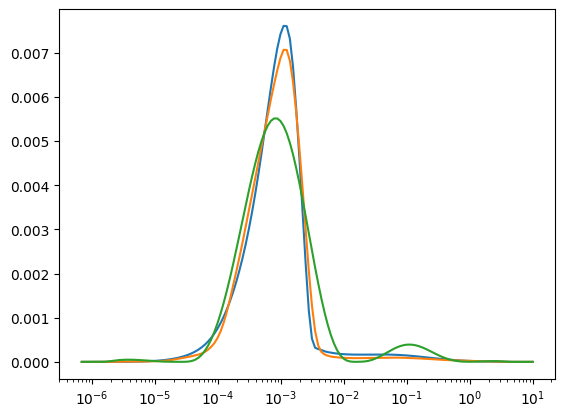

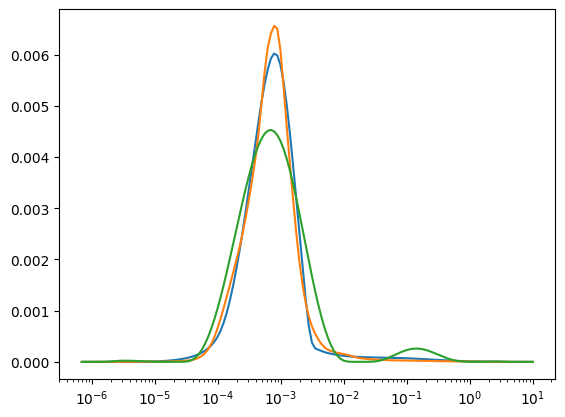

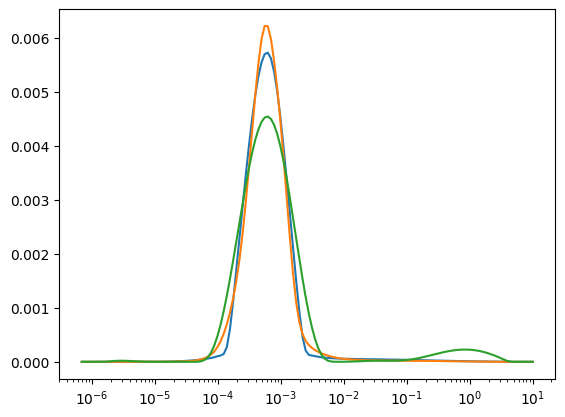

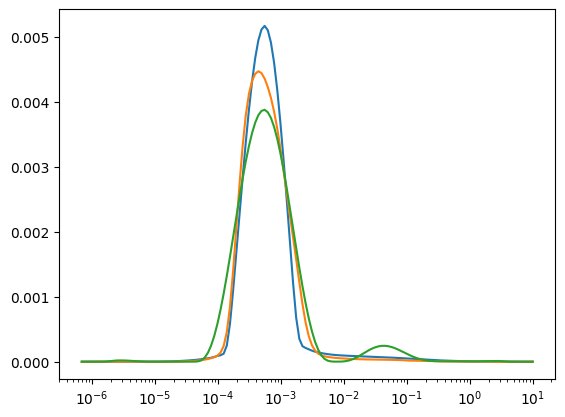

In [21]:
for tau,gamma,tau_hmc,gamma_hmc,tau_ridge,gamma_ridge in zip(tau_plots, gammas,tau_plots_hmc, gammas_hmc,tau_plots_ridge,gammas_ridge):
    plt.plot(tau,gamma)
    plt.plot(tau_hmc,gamma_hmc)
    plt.plot(tau_ridge,gamma_ridge)
    plt.xscale('log')
    plt.show()

